WHO Global Health Indicators
Can we predict a country's UHC Service Coverage Index from healthcare workforce density and government health expenditure?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
df = pd.read_csv('WHO_UHC.csv')

In [3]:
df.head()

,Location,LocationCode,doctors,nurses,pharmacists,gov_health_exp,UHC_index
0,Afghanistan,AFG,3.17,5.49,0.32,1.126057,40.88461
1,Albania,ALB,18.79,58.21,10.80,9.193673,63.76895
2,Algeria,DZA,16.60,25.08,3.00,5.361368,74.11164
3,Andorra,AND,50.68,47.22,9.77,15.870918,78.86248
4,Angola,AGO,2.44,18.73,0.40,6.699635,36.72917


In [4]:
print(df[df['UHC_index'].isnull()]['Location'].tolist())

['occupied Palestinian territory, including east Jerusalem']


In [5]:
print(df[df['pharmacists'].isnull()]['Location'].tolist())

['Antigua and Barbuda', 'Bahamas', 'Cook Islands', 'Cuba', 'Djibouti', 'Dominica', 'Honduras', 'Marshall Islands', 'Mexico', 'Micronesia (Federated States of)', 'Nicaragua', 'Niue', 'Saint Kitts and Nevis', 'Saint Vincent and the Grenadines', 'Somalia', 'Ukraine', 'Vanuatu', 'Venezuela (Bolivarian Republic of)', 'occupied Palestinian territory, including east Jerusalem']


In [6]:
print(df[df['doctors'].isnull()]['Location'].tolist())

['Kiribati', 'Marshall Islands', 'Niue', 'Saint Vincent and the Grenadines', 'Somalia', 'occupied Palestinian territory, including east Jerusalem']


In [7]:
print(df[df['nurses'].isnull()]['Location'].tolist())

['Monaco', 'Somalia', 'occupied Palestinian territory, including east Jerusalem']


In [8]:
print(df[df['gov_health_exp'].isnull()]['Location'].tolist())

["Democratic People's Republic of Korea", 'Ukraine']


UHC_index: 1 missing. Target variable, MUST drop this row
pharmacists: 19 missing including Ukraine, Venezuela, too many important countries - will drop this column 
doctors: 6 missing: Small Pacific island states + Somalia 
nurses:  3 missing: Monaco, Somalia, Palestinian territory
gov_health_exp: 2 missing: North Korea, Ukraine


In [10]:
#dropping Palestinian territory (missing target variable)

df = df.dropna(subset=['UHC_index'])
print("Dropped row with missing UHC_index:", df.shape)


Dropped row with missing UHC_index: (194, 7)


In [11]:
#Drop pharmacists column (too many missing values)

df = df.drop(columns=['pharmacists'])
print("Dropped 'pharmacists' column:", df.shape)

Dropped 'pharmacists' column: (194, 6)


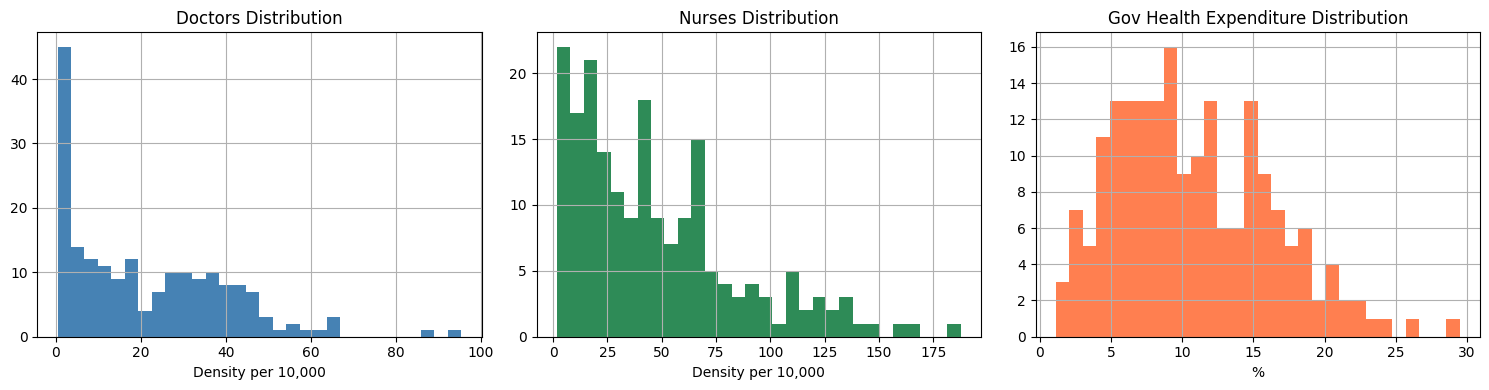

In [13]:
#Check distributions 

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['doctors'].hist(ax=axes[0], bins=30, color='steelblue')
axes[0].set_title('Doctors Distribution')
axes[0].set_xlabel('Density per 10,000')

df['nurses'].hist(ax=axes[1], bins=30, color='seagreen')
axes[1].set_title('Nurses Distribution')
axes[1].set_xlabel('Density per 10,000')

df['gov_health_exp'].hist(ax=axes[2], bins=30, color='coral')
axes[2].set_title('Gov Health Expenditure Distribution')
axes[2].set_xlabel('%')

plt.tight_layout()
plt.show()

Doctors are right skewed

Most countries clustered between 0-20 doctors per 10,000
Long tail stretching to the right toward 100
A few wealthy countries have extremely high doctor density
Use median

Nurses are also right skewed

Most countries clustered between 0-50 nurses per 10,000
Long tail stretching right toward 187
Similar pattern to doctors but more spread out
Use median

Gov Health Exp is almost symmetric

Much more spread between 0-30%
Looks roughly bell shaped around 10-15%
No extreme long tail in either direction
Use mean

In [14]:
#confirming skewness 

df[['doctors', 'nurses', 'gov_health_exp']].describe()

,doctors,nurses,gov_health_exp
count,189.000000,192.000000,192.000000
mean,21.142450,46.914635,10.817290
std,18.578643,38.407345,5.492681
min,0.380000,1.670000,1.126057
25%,4.240000,16.462500,6.613999
50%,16.670000,39.345000,9.811726
75%,34.560000,65.645000,14.850314
max,95.420000,187.600000,29.509142


Doctor density ranges from 0.38 to 95.42 per 10,000 people
a 250x difference between poorest and richest countries
Nurse density ranges from 1.67 to 187.60 per 10,000 people
even more extreme inequality
Gov health spending ranges from 1.13% to 29.51% of budget

50% of countries have fewer than 17 doctors per 10,000
50% of countries have fewer than 39 nurses per 10,000
50% of countries spend less than 10% of budget on health

The world average hides massive inequality between high and low income countries.

In [ ]:
# doctors & nurses: right skewed so filled up with median 
# gov_health_exp: almost symmetric so filled up with mean

df['doctors'] = df['doctors'].fillna(df['doctors'].median())
df['nurses'] = df['nurses'].fillna(df['nurses'].median())
df['gov_health_exp'] = df['gov_health_exp'].fillna(df['gov_health_exp'].mean())

In [16]:
print("Missing values after input:")
print(df.isnull().sum())
print(f"\n Final shape: {df.shape}")

Missing values after input:
Location          0
LocationCode      0
doctors           0
nurses            0
gov_health_exp    0
UHC_index         0
dtype: int64

 Final shape: (194, 6)


In [17]:
#Summary statistics of clean dataset

df[['doctors', 'nurses', 'gov_health_exp', 'UHC_index']].describe().round(2)

,doctors,nurses,gov_health_exp,UHC_index
count,194.00,194.00,194.00,194.00
mean,21.03,46.84,10.82,64.29
std,18.35,38.22,5.46,15.21
min,0.38,1.67,1.13,26.79
25%,4.61,16.65,6.66,51.67
50%,16.67,39.34,9.98,68.69
75%,34.04,65.59,14.82,78.56
max,95.42,187.60,29.51,80.00


No missing data
World average UHC score is only 64/100
Worst covered country has score of just 27
Maximum is exactly 80 — ceiling effect!
Half the world scores below 69

CEILING EFFECT

The UHC index in this dataset cannot go above 80 — it's the maximum possible score.

For example: 
Reality:          85, 88, 91, 92, 95
What data shows:  80, 80, 80, 80, 80

This limits our regression accuracy for high-performing countries
# dataset limitation.

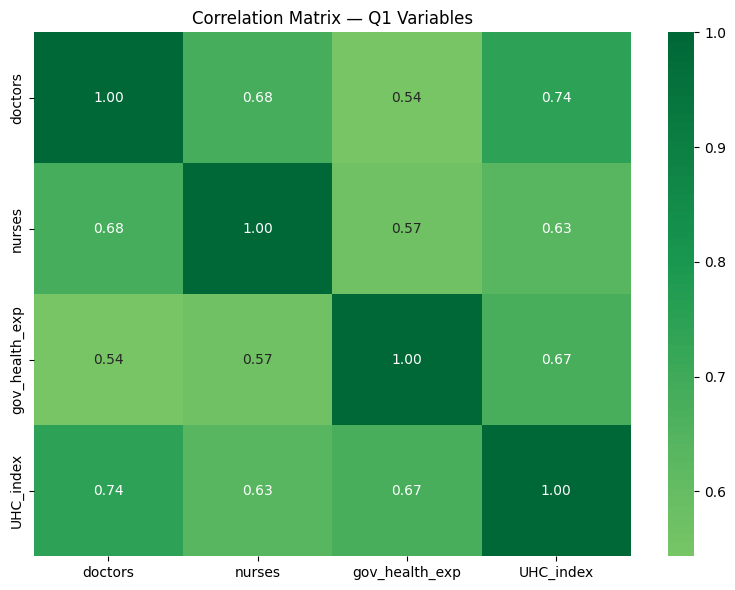

In [18]:
#Correlation matrix: shows how strongly each variable relates to the others

plt.figure(figsize=(8, 6))
corr = df[['doctors', 'nurses', 'gov_health_exp', 'UHC_index']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Correlation Matrix — Q1 Variables')
plt.tight_layout()
plt.show()

Doctors and nurses correlate 0.68 with each other — this is called multicollinearity and means they carry overlapping information.

In regression, having two highly correlated predictors is like getting the same information twice — one becomes redundant.

Doctors: 0.74 strongest predictor 
Gov health exp: 0.67 strong predictor 
Nurses: 0.63 moderate-strong predictor

Doctors and nurses correlate 0.68 with each other. They carry overlapping information
This may cause nurses to appear insignificant in regression

To be  investigated later!!!

Doctor density is the strongest single predictor of UHC coverage globally.

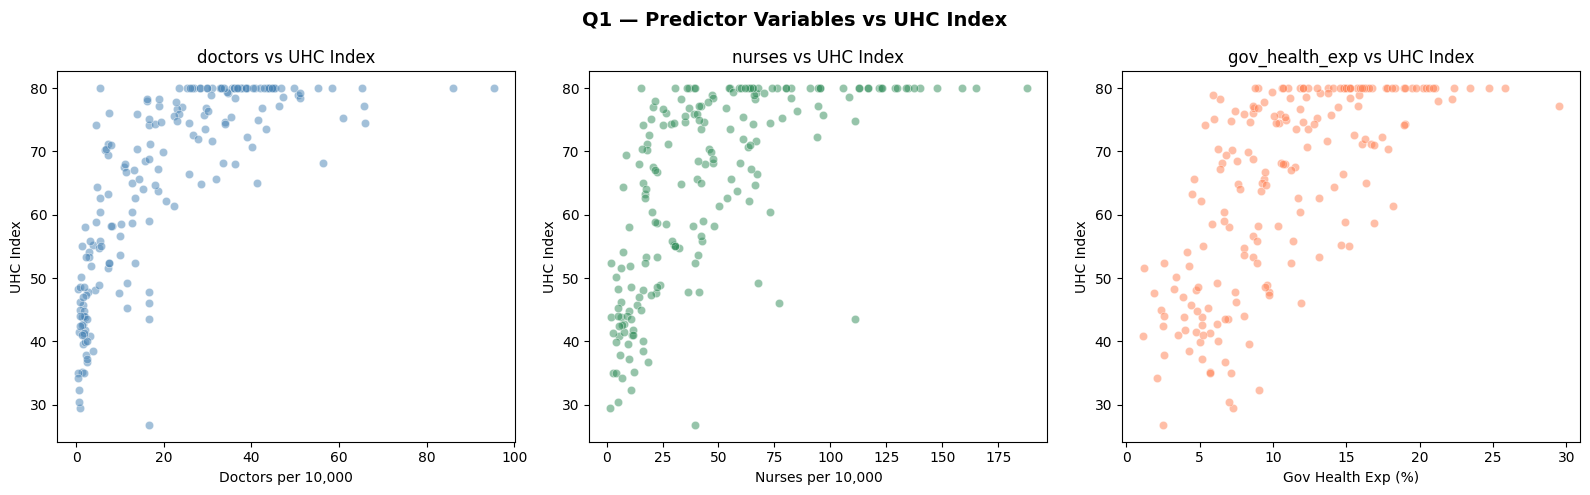

In [19]:
#Scatter plots: show the relationship between each predictor and UHC index

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

variables = ['doctors', 'nurses', 'gov_health_exp']
colors = ['steelblue', 'seagreen', 'coral']
labels = ['Doctors per 10,000', 'Nurses per 10,000', 'Gov Health Exp (%)']

for ax, var, color, label in zip(axes, variables, colors, labels):
    ax.scatter(df[var], df['UHC_index'],
               alpha=0.5, color=color, 
               edgecolors='white', linewidth=0.5)
    ax.set_xlabel(label)
    ax.set_ylabel('UHC Index')
    ax.set_title(f'{var} vs UHC Index')

plt.suptitle('Q1 — Predictor Variables vs UHC Index', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Doctors vs UHC 

Clear upward trend: more doctors = higher UHC 
But relationship is curved not straight, rises fast at low values then flattens
Ceiling effect visible, many dots stuck at UHC=80
Most countries clustered at 0-20 doctors, confirming right skew
Logarithmic relationship, log transformation needed

Nurses vs UHC

Similar curved upward pattern as doctors
Even more clustering at low nurse density (0-50)
Ceiling effect also visible at UHC=80
Relationship exists but weaker than doctors visually
Also needs log transformation

Gov Health Exp vs UHC

Weakest visual relationship of the three
Very scattered, spending alone doesn't guarantee coverage
No clear curve
Ceiling effect still visible at UHC=80
Linear relationship acceptable, no transformation needed

Why Log Transformation?

Scatter plots showed curved relationships between doctors/nurses and UHC index.

Linear regression assumes straight line relationships.
Log transformation straightens the curve by:
1. Compressing large values (wealthy countries with many doctors)
2. Stretching small values (poor countries with few doctors)

This better reflects reality — going from 1 to 5 doctors per 10,000 people has a much bigger impact than going from 80 to 84 doctors.

We use np.log1p() (log + 1) to handle countries with zero or near-zero values safely.

# Regression Models 
To  build 2 models to find the best one:
- Model 1: Raw variables (no transformation)
- Model 2: Log transformed doctors & nurses

In [20]:
#Model 1: UHC_index ~ doctors + nurses + gov_health_exp

# Define X and y
X1 = df[['doctors', 'nurses', 'gov_health_exp']]
y = df['UHC_index']

# Add constant 
X1_const = sm.add_constant(X1)

# Fit model
model1 = sm.OLS(y, X1_const).fit()

print("MODEL 1 — Raw Variables")
print(model1.summary())

MODEL 1 — Raw Variables
                            OLS Regression Results                            
Dep. Variable:              UHC_index   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.655
Method:                 Least Squares   F-statistic:                     123.2
Date:                Mon, 04 May 2026   Prob (F-statistic):           2.41e-44
Time:                        13:23:51   Log-Likelihood:                -698.00
No. Observations:                 194   AIC:                             1404.
Df Residuals:                     190   BIC:                             1417.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             43

R squared = 0.661 which explains 66% of UHC variation
F-statistic = 123.2, 
p≈0 --- model is statistically significant


- doctors: significant (p=0.000) — each extra doctor per 10,000 makes UHC +0.40
- gov_health_exp: significant (p=0.000) — each 1% more spending makes UHC +0.97
- nurses: NOT significant (p=0.075) — CI crosses zero [-0.004, 0.091]

nurses not significant — likely due to multicollinearity with doctors (r=0.68 from correlation matrix)

In [21]:
#MODEL 2: Log transformed

# Apply log transformation
df['log_doctors'] = np.log1p(df['doctors'])
df['log_nurses'] = np.log1p(df['nurses'])

# Define X2
X2 = df[['log_doctors', 'log_nurses', 'gov_health_exp']]
X2_const = sm.add_constant(X2)

# Fit model
model2 = sm.OLS(y, X2_const).fit()

print("MODEL 2 — Log Transformed")
print(model2.summary())

MODEL 2 — Log Transformed
                            OLS Regression Results                            
Dep. Variable:              UHC_index   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     225.2
Date:                Mon, 04 May 2026   Prob (F-statistic):           2.63e-62
Time:                        13:27:27   Log-Likelihood:                -655.69
No. Observations:                 194   AIC:                             1319.
Df Residuals:                     190   BIC:                             1332.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             

Even after log transformation nurses p-value got worse (0.075 → 0.555) and CI now crosses zero badly (-1.361 to 2.526). This strongly confirms multicollinearity with doctors.


- R squared increased from 0.661 → 0.781 (+12%) 
- F-statistic doubled from 123.2 → 225.2 


- log_doctors: significant (p=0.000) coef=9.40
- gov_health_exp: significant (p=0.000) coef=0.68
- log_nurses: NOT significant (p=0.555) CI crosses zero heavily

nurses p-value got worse after transformation
→ multicollinearity with doctors confirmed
→ Decision: drop nurses (don't add anything significant) → build Model 3

In [22]:
#Building model 3 without nurses 

X3 = df[['log_doctors', 'gov_health_exp']]
X3_const = sm.add_constant(X3)

model3 = sm.OLS(y, X3_const).fit()

print("MODEL 3 — Final Model")
print(model3.summary())

MODEL 3 — Final Model
                            OLS Regression Results                            
Dep. Variable:              UHC_index   R-squared:                       0.780
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     338.8
Date:                Mon, 04 May 2026   Prob (F-statistic):           1.50e-63
Time:                        13:31:32   Log-Likelihood:                -655.87
No. Observations:                 194   AIC:                             1318.
Df Residuals:                     191   BIC:                             1328.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             31.2

**Three models tested and compared:**

| Model | R squared | Predictors | All significant? |
|-------|-----|------------|-----------------|
| Model 1 (raw) | 0.661 | 3 |  No |
| Model 2 (log) | 0.781 | 3 |  No |
| Model 3 (log, no nurses) | 0.780 | 2 |  Yes |

Model 3
- Same R squared as Model 2 with one less variable
- Both predictors fully significant (p=0.000)
- Highest F-statistic (338.8) — strongest model overall

Final equation:
UHC = 31.24 + 9.76 × log(doctors) + 0.70 × gov_health_exp

Key findings:
- Doctor density is the strongest predictor of UHC coverage
- Each 1% increase in gov health budget adds 0.70 UHC points
- Together they explain 78% of UHC variation across 194 countries
- Nurses excluded due to multicollinearity with doctors

Confidence intervals (95%):
- log_doctors: [8.62, 10.90] — narrow and reliable
- gov_health_exp: [0.46, 0.93] — narrow and reliable

F-statistic tells us whether our predictors together are genuinely useful for predicting UHC — or whether we might as well just use the global average. Our F=338.8 with p≈0 confirms our model is highly significant.

# Visualizations 